In [ ]:
#This notebook loads and inspects the raw circuit and count data for the 2-qubit Bell-state decoherence. Organising data. Visualizing how measured outcomes evolve across delay times. 
import json
from pathlib import Path
from qiskit import qpy
import pandas as pd 
import matplotlib.pyplot as plt 
data_dir = Path("../../data/bell_2q_decoherence")
with open(data_dir / "2_circuitsraw_64.qpy", "rb") as f:
    circuits_raw = qpy.load(f)


with open(data_dir / "2_counts_64.json", "r", encoding="utf-8") as f:
    counts = json.load(f)

print("raw circuits:", len(circuits_raw))
print("counts entries:", len(counts))

print(circuits_raw[0].draw("text"))
print(circuits_raw[16].draw("text"))
print(circuits_raw[32].draw("text"))
print(circuits_raw[48].draw("text"))

raw circuits: 64
counts entries: 64
     ┌───┐      ░ ┌─┐   
q_0: ┤ H ├──■───░─┤M├───
     └───┘┌─┴─┐ ░ └╥┘┌─┐
q_1: ─────┤ X ├─░──╫─┤M├
          └───┘ ░  ║ └╥┘
c: 2/══════════════╩══╩═
                   0  1 
     ┌───┐     ┌─────────────────┐ ░ ┌─┐   
q_0: ┤ H ├──■──┤ Delay(4000[dt]) ├─░─┤M├───
     └───┘┌─┴─┐├─────────────────┤ ░ └╥┘┌─┐
q_1: ─────┤ X ├┤ Delay(4000[dt]) ├─░──╫─┤M├
          └───┘└─────────────────┘ ░  ║ └╥┘
c: 2/═════════════════════════════════╩══╩═
                                      0  1 
     ┌───┐     ┌─────────────────┐ ░ ┌─┐   
q_0: ┤ H ├──■──┤ Delay(8000[dt]) ├─░─┤M├───
     └───┘┌─┴─┐├─────────────────┤ ░ └╥┘┌─┐
q_1: ─────┤ X ├┤ Delay(8000[dt]) ├─░──╫─┤M├
          └───┘└─────────────────┘ ░  ║ └╥┘
c: 2/═════════════════════════════════╩══╩═
                                      0  1 
     ┌───┐     ┌──────────────────┐ ░ ┌─┐   
q_0: ┤ H ├──■──┤ Delay(16000[dt]) ├─░─┤M├───
     └───┘┌─┴─┐├──────────────────┤ ░ └╥┘┌─┐
q_1: ─────┤ X ├┤ Delay(16000[dt]) ├─░─

In [2]:
def time_label(i):
    if 0 <= i <= 15:
        return "t0"
    elif 16 <= i <= 31:
        return "t1_4000dt"
    elif 32 <= i <= 47:
        return "t2_8000dt"
    elif 48 <= i <= 63:
        return "t3_16000dt"
    else:
        return "unknown"

for i in [0, 1, 2, 3, 16, 17, 32, 48]:
    print(f"\n=== index {i} | {time_label(i)} ===")
    print("ops:", circuits_raw[i].count_ops())
    print("counts:", counts[i])
    print(circuits_raw[i].draw("text"))


=== index 0 | t0 ===
ops: OrderedDict({'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1})
counts: {'00': 497, '11': 468, '10': 18, '01': 17}
     ┌───┐      ░ ┌─┐   
q_0: ┤ H ├──■───░─┤M├───
     └───┘┌─┴─┐ ░ └╥┘┌─┐
q_1: ─────┤ X ├─░──╫─┤M├
          └───┘ ░  ║ └╥┘
c: 2/══════════════╩══╩═
                   0  1 

=== index 1 | t0 ===
ops: OrderedDict({'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1, 'x': 1})
counts: {'01': 496, '10': 468, '00': 33, '11': 3}
     ┌───┐      ░      ┌─┐   
q_0: ┤ H ├──■───░──────┤M├───
     └───┘┌─┴─┐ ░ ┌───┐└╥┘┌─┐
q_1: ─────┤ X ├─░─┤ X ├─╫─┤M├
          └───┘ ░ └───┘ ║ └╥┘
c: 2/═══════════════════╩══╩═
                        0  1 

=== index 2 | t0 ===
ops: OrderedDict({'h': 2, 'measure': 2, 'cx': 1, 'barrier': 1})
counts: {'01': 263, '00': 248, '10': 253, '11': 236}
     ┌───┐      ░      ┌─┐   
q_0: ┤ H ├──■───░──────┤M├───
     └───┘┌─┴─┐ ░ ┌───┐└╥┘┌─┐
q_1: ─────┤ X ├─░─┤ H ├─╫─┤M├
          └───┘ ░ └───┘ ║ └╥┘
c: 2/═══════════════════╩══╩═
               

In [3]:
def time_label(i):
    if 0 <= i <= 15:
        return "t0_0dt"
    elif 16 <= i <= 31:
        return "t1_4000dt"
    elif 32 <= i <= 47:
        return "t2_8000dt"
    elif 48 <= i <= 63:
        return "t3_16000dt"
    else:
        return "unknown"

rows = []
for i, qc in enumerate(circuits_raw):
    ops = qc.count_ops()
    total_shots = sum(counts[i].values())
    rows.append({
        "index": i,
        "time_block": i // 16,
        "time_label": time_label(i),
        "basis_index": i % 16,
        "has_delay": "delay" in ops,
        "delay_count": ops.get("delay", 0),
        "ops": dict(ops),
        "shots": total_shots,
        "counts_00": counts[i].get("00", 0),
        "counts_01": counts[i].get("01", 0),
        "counts_10": counts[i].get("10", 0),
        "counts_11": counts[i].get("11", 0),
    })

df = pd.DataFrame(rows)
df.head(20)

,index,time_block,time_label,basis_index,has_delay,delay_count,ops,shots,counts_00,counts_01,counts_10,counts_11
0,0,0,t0_0dt,0,False,0,"{'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1}",1000,497,17,18,468
1,1,0,t0_0dt,1,False,0,"{'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1, ...",1000,33,496,468,3
2,2,0,t0_0dt,2,False,0,"{'h': 2, 'measure': 2, 'cx': 1, 'barrier': 1}",1000,248,263,253,236
3,3,0,t0_0dt,3,False,0,"{'h': 2, 'measure': 2, 'cx': 1, 'barrier': 1, ...",1000,282,248,233,237
4,4,0,t0_0dt,4,False,0,"{'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1, ...",1000,26,483,476,15
5,5,0,t0_0dt,5,False,0,"{'x': 2, 'measure': 2, 'h': 1, 'cx': 1, 'barri...",1000,502,17,20,461
6,6,0,t0_0dt,6,False,0,"{'h': 2, 'measure': 2, 'cx': 1, 'barrier': 1, ...",1000,253,303,231,213
7,7,0,t0_0dt,7,False,0,"{'h': 2, 'measure': 2, 'cx': 1, 'barrier': 1, ...",1000,227,287,261,225
8,8,0,t0_0dt,8,False,0,"{'h': 2, 'measure': 2, 'cx': 1, 'barrier': 1}",1000,265,276,249,210
9,9,0,t0_0dt,9,False,0,"{'h': 2, 'measure': 2, 'cx': 1, 'barrier': 1, ...",1000,229,273,274,224


In [4]:
df[["index", "time_label", "basis_index", "shots", "counts_00", "counts_01", "counts_10", "counts_11"]]

,index,time_label,basis_index,shots,counts_00,counts_01,counts_10,counts_11
0,0,t0_0dt,0,1000,497,17,18,468
1,1,t0_0dt,1,1000,33,496,468,3
2,2,t0_0dt,2,1000,248,263,253,236
3,3,t0_0dt,3,1000,282,248,233,237
4,4,t0_0dt,4,1000,26,483,476,15
...,...,...,...,...,...,...,...,...
59,59,t3_16000dt,11,1000,250,269,248,233
60,60,t3_16000dt,12,1000,377,389,119,115
61,61,t3_16000dt,13,1000,117,108,387,388
62,62,t3_16000dt,14,1000,261,247,252,240


In [5]:
df["p_00"] = df["counts_00"] / df["shots"]
df["p_01"] = df["counts_01"] / df["shots"]
df["p_10"] = df["counts_10"] / df["shots"]
df["p_11"] = df["counts_11"] / df["shots"]

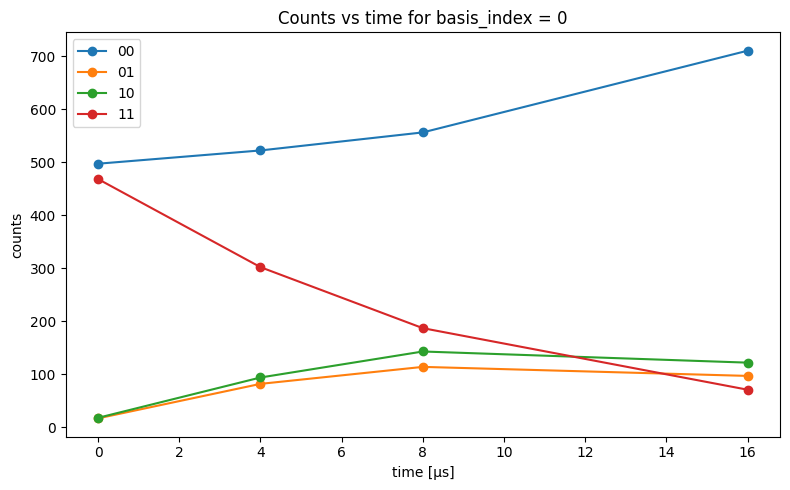

In [6]:
basis_id = 0

sub = df[df["basis_index"] == basis_id].copy()
sub["time_us"] = [0, 4, 8, 16]

plt.figure(figsize=(8,5))
plt.plot(sub["time_us"], sub["counts_00"], marker="o", label="00")
plt.plot(sub["time_us"], sub["counts_01"], marker="o", label="01")
plt.plot(sub["time_us"], sub["counts_10"], marker="o", label="10")
plt.plot(sub["time_us"], sub["counts_11"], marker="o", label="11")
plt.xlabel("time [µs]")
plt.ylabel("counts")
plt.title(f"Counts vs time for basis_index = {basis_id}")
plt.legend()
plt.tight_layout()
plt.show()

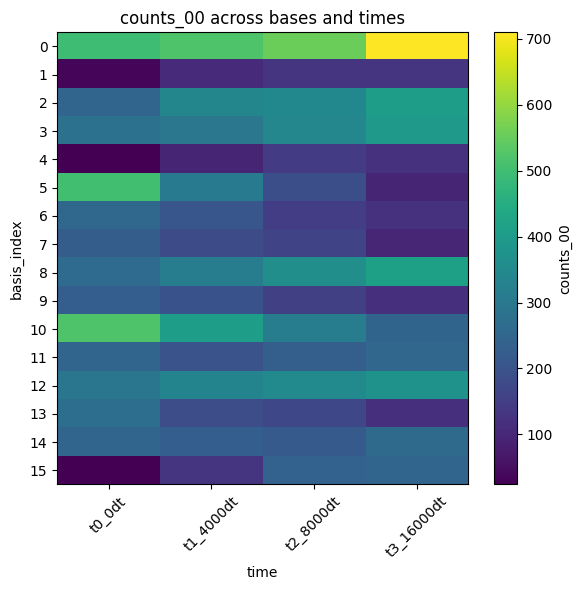

In [7]:
pivot_00 = df.pivot(index="basis_index", columns="time_label", values="counts_00")

plt.figure(figsize=(6,6))
plt.imshow(pivot_00.values, aspect="auto")
plt.xticks(range(len(pivot_00.columns)), pivot_00.columns, rotation=45)
plt.yticks(range(len(pivot_00.index)), pivot_00.index)
plt.xlabel("time")
plt.ylabel("basis_index")
plt.title("counts_00 across bases and times")
plt.colorbar(label="counts_00")
plt.tight_layout()
plt.show()